# Notebook 4 — Spark analysis, Spark SQL, and visual insights

This notebook is the **main analytics** step of the project pipeline.

It is designed to:

- load the processed analytical base dataset created in **Notebook 3**
- answer a **small number of strong analytical questions**
- show both the **PySpark DataFrame API** and **Spark SQL**
- include a few realistic **Spark optimization touches**
- produce clear tables and visualizations for the final report and presentation

The notebook focuses on five analysis themes:

1. **rating patterns**
2. **verified vs non-verified purchase behavior**
3. **helpful-vote patterns**
4. **product / category / platform trends**
5. **time-based trends**


## Assumptions

1. **Notebook 3 has already been run successfully**.
2. The processed analytical base dataset exists under `data/processed/video_games_analytical_base/`.
3. We use the cleaned fields created in Notebook 3, especially:
   - `parent_asin`
   - `product_title`
   - `categories_clean`
   - `price_value`
   - `rating`
   - `verified_purchase`
   - `helpful_vote`
   - `review_ts`
   - `review_year`
   - `review_month`
   - `review_year_month`
4. This notebook is for **analysis**, not for heavy preprocessing.


## 1. Imports


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.storagelevel import StorageLevel


## 2. Environment setup (especially important on Windows)

This notebook mirrors **Notebook 3** for local file access on Windows.

If you are running on Windows and used a local Hadoop / `winutils` setup in Notebook 3,
we apply the same environment configuration here before starting Spark.


In [2]:
import os
from pathlib import Path

if os.name == "nt":
    hadoop_home = Path(r"C:\hadoop")
    if hadoop_home.exists():
        os.environ["HADOOP_HOME"] = str(hadoop_home)
        hadoop_bin = str(hadoop_home / "bin")
        if hadoop_bin not in os.environ["PATH"]:
            os.environ["PATH"] = os.environ["PATH"] + ";" + hadoop_bin
        print(f"Windows detected. Using HADOOP_HOME={hadoop_home}")
    else:
        print(
            "Windows detected, but C:\\hadoop was not found. "
            "If Parquet read/write fails, install/configure Hadoop winutils "
            "the same way as in Notebook 3."
        )
else:
    print("Non-Windows OS detected. Skipping HADOOP_HOME setup.")


Windows detected. Using HADOOP_HOME=C:\hadoop


## 3. Define paths and start Spark

We load the processed Parquet dataset from Notebook 3 and start a Spark session configured for analytical work.

This version resolves the **project root** first, so the notebook works even if the current
working directory is not exactly the `notebooks/` folder.


In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Make sure the notebook is inside the project repository."
    )

PROJECT_ROOT = find_project_root()
BASE_PATH = PROJECT_ROOT / "data" / "processed" / "video_games_analytical_base"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_PATH.exists(), f"Missing processed dataset directory: {BASE_PATH}"

spark = (
    SparkSession.builder
    .appName("Notebook_4_Spark_Analysis_Amazon_Video_Games")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.autoBroadcastJoinThreshold", 10 * 1024 * 1024)
    .config("spark.driver.memory", "3g")
    .config("spark.memory.fraction", "0.8")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")
print(f"Working directory: {Path.cwd().resolve()}")
print(f"Project root:      {PROJECT_ROOT}")
print(f"Processed path:    {BASE_PATH}")
print(f"Results path:      {RESULTS_DIR}")


Spark version: 4.1.1
Working directory: C:\Users\vilki\Desktop\Data_science scuuf\big-data-video-games-reviews\notebooks
Project root:      C:\Users\vilki\Desktop\Data_science scuuf\big-data-video-games-reviews
Processed path:    C:\Users\vilki\Desktop\Data_science scuuf\big-data-video-games-reviews\data\processed\video_games_analytical_base
Results path:      C:\Users\vilki\Desktop\Data_science scuuf\big-data-video-games-reviews\results


## 4. Confirm the Parquet output from Notebook 3

Before loading the dataset, we verify that the processed folder exists and contains Parquet files.
This helps diagnose path issues early.


In [4]:
folder_items = sorted(p.name for p in BASE_PATH.iterdir())
parquet_files = sorted(str(p.name) for p in BASE_PATH.rglob("*.parquet"))

print("Folder preview:")
print(folder_items[:20])

print(f"Parquet files found: {len(parquet_files)}")
print(parquet_files[:10])

assert parquet_files, (
    f"No parquet files found under {BASE_PATH}. "
    "Re-run Notebook 3 and confirm where the output was written."
)


Folder preview:
['._SUCCESS.crc', '.part-00000-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00001-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00002-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00003-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00004-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00005-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00006-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00007-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00008-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00009-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00010-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00011-13b7b644-143c-4960-8561-2fc2ec10fb41-c000.snappy.parquet.crc', '.part-00012-13b7b644-143c-4960-8561-2fc2ec10fb41-c000

## 5. Load the analytical base dataset

This dataset was prepared in Notebook 3 and already includes the review/metadata join on `parent_asin`.

We read from the absolute resolved path to avoid relative-path problems.


In [5]:
try:
    base_df = spark.read.parquet(str(BASE_PATH.resolve()))
except Exception:
    print(f"Failed to read parquet from: {BASE_PATH.resolve()}")
    print("Folder contents:")
    for p in sorted(BASE_PATH.iterdir()):
        print(" -", p.name)
    raise

print(f"Rows: {base_df.count():,}")
print(f"Distinct products: {base_df.select('parent_asin').distinct().count():,}")
print(f"Distinct users: {base_df.select('user_id').distinct().count():,}")

base_df.printSchema()
base_df.show(5, truncate=False)


Rows: 4,624,615
Distinct products: 137,249
Distinct users: 2,766,656
root
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- categories_clean: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- category_count: integer (nullable = true)
 |-- store_clean: string (nullable = true)
 |-- price_value: double (nullable = true)
 |-- rating: double (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- review_text_length: integer (nullable = true)
 |-- review_timestamp_ms: long (nullable = true)
 |-- review_ts: timestamp (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_month: integer (nullable = true)
 |-- review_year_month: timestamp (nullable = true)
 |-- has_price: boolean (nullable = true)
 |-- has_categories: boolean

## 6. Quick validation of the reused base table

Before analysis, we run a compact validation check on the main variables that will drive the notebook.


In [6]:
validation_df = base_df.agg(
    F.count("*").alias("rows"),
    F.sum(F.when(F.col("rating").isNull(), 1).otherwise(0)).alias("null_rating"),
    F.sum(F.when(F.col("verified_purchase").isNull(), 1).otherwise(0)).alias("null_verified_purchase"),
    F.sum(F.when(F.col("helpful_vote").isNull(), 1).otherwise(0)).alias("null_helpful_vote"),
    F.sum(F.when(F.col("product_title").isNull(), 1).otherwise(0)).alias("null_product_title"),
    F.sum(F.when(F.col("review_year_month").isNull(), 1).otherwise(0)).alias("null_review_year_month")
)

validation_df.show(truncate=False)


+-------+-----------+----------------------+-----------------+------------------+----------------------+
|rows   |null_rating|null_verified_purchase|null_helpful_vote|null_product_title|null_review_year_month|
+-------+-----------+----------------------+-----------------+------------------+----------------------+
|4624615|0          |0                     |0                |0                 |0                     |
+-------+-----------+----------------------+-----------------+------------------+----------------------+



## 7. Cache the reused base table and create a temp view

The base dataset will be reused across multiple analyses.  
Since it will be queried several times, caching is justified here.

We also register a temp view so the same dataset can be queried with Spark SQL.


In [7]:
base_df = base_df.persist(StorageLevel.MEMORY_AND_DISK)
base_df.count()  # materialize cache

base_df.createOrReplaceTempView("video_game_reviews")

print("Base DataFrame cached and temp view created: video_game_reviews")


Base DataFrame cached and temp view created: video_game_reviews


## 8. Analysis roadmap

We keep the analysis focused on a few strong questions instead of many weak charts:

- How are ratings distributed?
- Do verified and non-verified purchases behave differently?
- How do helpful votes relate to rating and verification status?
- Which categories, platforms, and products stand out?
- How do review activity and average rating evolve over time?


## 9. Rating patterns

We start with the most basic project question: how ratings are distributed across the dataset.

In [8]:
rating_dist_df = (
    base_df
    .groupBy("rating")
    .agg(F.count("*").alias("review_count"))
    .orderBy("rating")
)

rating_dist_df.show()


+------+------------+
|rating|review_count|
+------+------------+
|   1.0|      589519|
|   2.0|      249878|
|   3.0|      340086|
|   4.0|      617251|
|   5.0|     2827881|
+------+------------+



In [9]:
rating_summary_sql = spark.sql(
    '''
    SELECT
        rating,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_reviews
    FROM video_game_reviews
    GROUP BY rating
    ORDER BY rating
    '''
)

rating_summary_sql.show()


+------+------------+--------------+
|rating|review_count|pct_of_reviews|
+------+------------+--------------+
|   1.0|      589519|         12.75|
|   2.0|      249878|          5.40|
|   3.0|      340086|          7.35|
|   4.0|      617251|         13.35|
|   5.0|     2827881|         61.15|
+------+------------+--------------+



### 9.1 The execution plan

This cell shows Spark SQL optimization in the notebook.


In [10]:
print("=== Execution plan for rating distribution query ===")
rating_dist_df.explain(True)


=== Execution plan for rating distribution query ===
== Parsed Logical Plan ==
'Sort ['rating ASC NULLS FIRST], true
+- Aggregate [rating#8], [rating#8, count(1) AS review_count#813L]
   +- Relation [parent_asin#0,user_id#1,product_title#2,main_category#3,categories_clean#4,category_count#5,store_clean#6,price_value#7,rating#8,verified_purchase#9,helpful_vote#10L,review_text_length#11,review_timestamp_ms#12L,review_ts#13,review_date#14,review_year#15,review_month#16,review_year_month#17,has_price#18,has_categories#19] parquet

== Analyzed Logical Plan ==
rating: double, review_count: bigint
Sort [rating#8 ASC NULLS FIRST], true
+- Aggregate [rating#8], [rating#8, count(1) AS review_count#813L]
   +- Relation [parent_asin#0,user_id#1,product_title#2,main_category#3,categories_clean#4,category_count#5,store_clean#6,price_value#7,rating#8,verified_purchase#9,helpful_vote#10L,review_text_length#11,review_timestamp_ms#12L,review_ts#13,review_date#14,review_year#15,review_month#16,review_yea

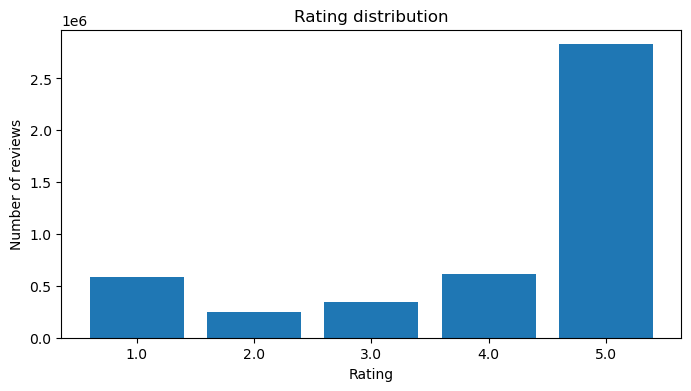

In [11]:
rating_pd = rating_summary_sql.toPandas()

plt.figure(figsize=(8, 4))
plt.bar(rating_pd["rating"].astype(str), rating_pd["review_count"])
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.show()


## 10. Verified vs non-verified purchase behavior

This section tests whether verified purchases differ from non-verified ones in:
- review volume
- average rating
- average helpful votes
- average review length


In [12]:
verified_behavior_df = (
    base_df
    .groupBy("verified_purchase")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_vote"),
        F.expr("percentile_approx(helpful_vote, 0.5)").alias("median_helpful_vote"),
        F.avg("review_text_length").alias("avg_review_text_length")
    )
    .orderBy("verified_purchase")
)

verified_behavior_df.show(truncate=False)


+-----------------+------------+------------------+-----------------+-------------------+----------------------+
|verified_purchase|review_count|avg_rating        |avg_helpful_vote |median_helpful_vote|avg_review_text_length|
+-----------------+------------+------------------+-----------------+-------------------+----------------------+
|false            |641808      |3.7310270361229527|3.32719130955052 |0                  |800.341036571685      |
|true             |3982807     |4.098450916652502 |0.889707183903212|0                  |228.19060125183069    |
+-----------------+------------+------------------+-----------------+-------------------+----------------------+



In [13]:
verified_behavior_sql = spark.sql(
    '''
    SELECT
        verified_purchase,
        COUNT(*) AS review_count,
        ROUND(AVG(rating), 4) AS avg_rating,
        ROUND(AVG(helpful_vote), 4) AS avg_helpful_vote,
        ROUND(AVG(review_text_length), 2) AS avg_review_text_length
    FROM video_game_reviews
    GROUP BY verified_purchase
    ORDER BY verified_purchase
    '''
)

verified_behavior_sql.show(truncate=False)


+-----------------+------------+----------+----------------+----------------------+
|verified_purchase|review_count|avg_rating|avg_helpful_vote|avg_review_text_length|
+-----------------+------------+----------+----------------+----------------------+
|false            |641808      |3.731     |3.3272          |800.34                |
|true             |3982807     |4.0985    |0.8897          |228.19                |
+-----------------+------------+----------+----------------+----------------------+



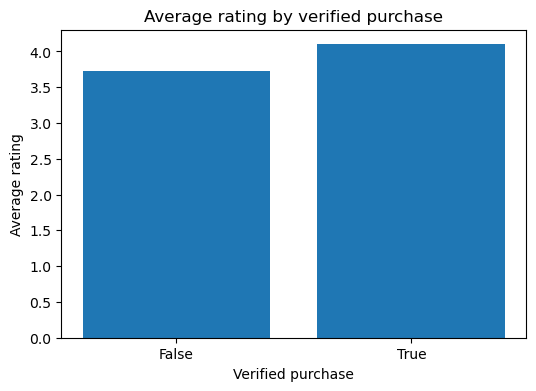

In [14]:
verified_pd = verified_behavior_df.toPandas()

plt.figure(figsize=(6, 4))
plt.bar(verified_pd["verified_purchase"].astype(str), verified_pd["avg_rating"])
plt.title("Average rating by verified purchase")
plt.xlabel("Verified purchase")
plt.ylabel("Average rating")
plt.show()


## 11. Helpful-vote patterns

Helpful votes are highly skewed in review datasets, so this section should focus on:
- the share of zero-helpful-vote reviews
- median vs average helpful votes
- how helpful votes vary by rating and verification status


In [15]:
helpful_summary_df = base_df.agg(
    F.count("*").alias("rows"),
    F.avg("helpful_vote").alias("avg_helpful_vote"),
    F.max("helpful_vote").alias("max_helpful_vote"),
    F.expr("percentile_approx(helpful_vote, array(0.5, 0.9, 0.99))").alias("helpful_vote_percentiles"),
    F.sum(F.when(F.col("helpful_vote") == 0, 1).otherwise(0)).alias("zero_helpful_votes")
)

helpful_summary_df.show(truncate=False)


+-------+-----------------+----------------+------------------------+------------------+
|rows   |avg_helpful_vote |max_helpful_vote|helpful_vote_percentiles|zero_helpful_votes|
+-------+-----------------+----------------+------------------------+------------------+
|4624615|1.227983302393821|10369           |[0, 2, 18]              |3456888           |
+-------+-----------------+----------------+------------------------+------------------+



In [16]:
helpful_by_group_df = (
    base_df
    .groupBy("verified_purchase", "rating")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("helpful_vote").alias("avg_helpful_vote"),
        F.expr("percentile_approx(helpful_vote, 0.5)").alias("median_helpful_vote")
    )
    .orderBy("verified_purchase", "rating")
)

helpful_by_group_df.show(truncate=False)


+-----------------+------+------------+------------------+-------------------+
|verified_purchase|rating|review_count|avg_helpful_vote  |median_helpful_vote|
+-----------------+------+------------+------------------+-------------------+
|false            |1.0   |107988      |5.5171870948623924|1                  |
|false            |2.0   |48861       |3.5006242197253434|1                  |
|false            |3.0   |61612       |3.612169707199896 |1                  |
|false            |4.0   |112678      |3.2132714460675555|0                  |
|false            |5.0   |310669      |2.523476755002913 |0                  |
|true             |1.0   |481531      |1.6847181178366502|0                  |
|true             |2.0   |201017      |1.1659511384609262|0                  |
|true             |3.0   |278474      |1.060382656908724 |0                  |
|true             |4.0   |504573      |0.9299744536469451|0                  |
|true             |5.0   |2517212     |0.68861224243

In [17]:
helpful_by_group_sql = spark.sql(
    '''
    SELECT
        verified_purchase,
        rating,
        COUNT(*) AS review_count,
        ROUND(AVG(helpful_vote), 4) AS avg_helpful_vote
    FROM video_game_reviews
    GROUP BY verified_purchase, rating
    ORDER BY verified_purchase, rating
    '''
)

helpful_by_group_sql.show(truncate=False)


+-----------------+------+------------+----------------+
|verified_purchase|rating|review_count|avg_helpful_vote|
+-----------------+------+------------+----------------+
|false            |1.0   |107988      |5.5172          |
|false            |2.0   |48861       |3.5006          |
|false            |3.0   |61612       |3.6122          |
|false            |4.0   |112678      |3.2133          |
|false            |5.0   |310669      |2.5235          |
|true             |1.0   |481531      |1.6847          |
|true             |2.0   |201017      |1.166           |
|true             |3.0   |278474      |1.0604          |
|true             |4.0   |504573      |0.93            |
|true             |5.0   |2517212     |0.6886          |
+-----------------+------+------------+----------------+



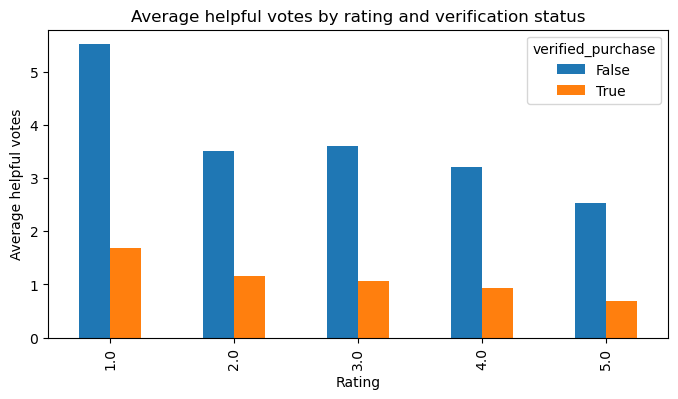

In [18]:
helpful_pd = helpful_by_group_df.toPandas()

pivot_helpful = helpful_pd.pivot(index="rating", columns="verified_purchase", values="avg_helpful_vote")
pivot_helpful.plot(kind="bar", figsize=(8, 4))
plt.title("Average helpful votes by rating and verification status")
plt.xlabel("Rating")
plt.ylabel("Average helpful votes")
plt.show()


## 12. Product, category, and platform trends

Notebook 2 showed that `main_category` is not strong enough on its own, while `categories` is more informative.  
So here we rely on `categories_clean` from Notebook 3 and explode it for category-level analysis.

To make the later platform grouping safer, we also attach a lightweight `review_row_id` before exploding categories.


In [19]:
categories_exploded_df = (
    base_df
    .withColumn("review_row_id", F.monotonically_increasing_id())
    .select(
        "review_row_id",
        "parent_asin",
        "product_title",
        "rating",
        "verified_purchase",
        "helpful_vote",
        "review_year",
        F.explode_outer("categories_clean").alias("category")
    )
    .filter(F.col("category").isNotNull())
)

categories_exploded_df.show(20, truncate=False)


+-------------+-----------+----------------------------------------------------------------------------------------------+------+-----------------+------------+-----------+-----------+
|review_row_id|parent_asin|product_title                                                                                 |rating|verified_purchase|helpful_vote|review_year|category   |
+-------------+-----------+----------------------------------------------------------------------------------------------+------+-----------------+------------+-----------+-----------+
|0            |0008288194 |The Creativity Code                                                                           |3.0   |true             |1           |2022       |Video Games|
|0            |0008288194 |The Creativity Code                                                                           |3.0   |true             |1           |2022       |PC         |
|0            |0008288194 |The Creativity Code                             

In [20]:
top_categories_df = (
    categories_exploded_df
    .groupBy("category")
    .agg(
        F.count("*").alias("review_count"),
        F.countDistinct("parent_asin").alias("distinct_products"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_vote")
    )
    .filter(F.col("review_count") >= 500)
    .orderBy(F.desc("review_count"))
)

top_categories_df.show(20, truncate=False)


+-------------------------------+------------+-----------------+------------------+------------------+
|category                       |review_count|distinct_products|avg_rating        |avg_helpful_vote  |
+-------------------------------+------------+-----------------+------------------+------------------+
|Video Games                    |4485859     |124608           |4.050300065160318 |1.228163658287075 |
|Accessories                    |2280191     |63118            |3.993185220010078 |0.8168460449146585|
|Legacy Systems                 |1693340     |50922            |4.1310274368998545|1.2416714894823249|
|Games                          |1502718     |46528            |4.0969955773471805|1.712392478162902 |
|PC                             |1217396     |37496            |3.8990139609461507|1.3321860758537074|
|Nintendo Systems               |744755      |23524            |4.188388127639291 |1.19020214701479  |
|PlayStation Systems            |524934      |14986            |4.1174890

In [21]:
categories_exploded_df.createOrReplaceTempView("video_game_categories")

top_categories_sql = spark.sql(
    '''
    SELECT
        category,
        COUNT(*) AS review_count,
        COUNT(DISTINCT parent_asin) AS distinct_products,
        ROUND(AVG(rating), 4) AS avg_rating
    FROM video_game_categories
    GROUP BY category
    HAVING COUNT(*) >= 500
    ORDER BY review_count DESC
    LIMIT 20
    '''
)

top_categories_sql.show(truncate=False)


+-------------------------------+------------+-----------------+----------+
|category                       |review_count|distinct_products|avg_rating|
+-------------------------------+------------+-----------------+----------+
|Video Games                    |4485859     |124608           |4.0503    |
|Accessories                    |2280191     |63118            |3.9932    |
|Legacy Systems                 |1693340     |50922            |4.131     |
|Games                          |1502718     |46528            |4.097     |
|PC                             |1217396     |37496            |3.899     |
|Nintendo Systems               |744755      |23524            |4.1884    |
|PlayStation Systems            |524934      |14986            |4.1175    |
|PlayStation 4                  |443219      |10142            |4.0515    |
|Nintendo Switch                |440643      |12352            |4.2785    |
|Xbox One                       |424599      |6916             |3.9247    |
|Headsets   

### 12.1 Platform grouping with a broadcast join

This is still a realistic place to use a small broadcast dimension table.

The original keyword approach used simple substring matching, which can create false positives  
(for example, `DS` accidentally matching part of an unrelated word such as `Headsets`).

Here we tighten the logic in two ways:

1. normalize category text to a lowercase, punctuation-light form  
2. match each platform with a regex pattern that respects token boundaries

We also deduplicate to one `(review_row_id, platform_group)` match so that a single review is not counted
multiple times within the same platform just because several category labels matched.


In [22]:
platform_rules = [
    ("PlayStation", r"(^| )(playstation|ps5|ps4|ps3|ps2|ps vita|psp)( |$)", 1),
    ("Xbox", r"(^| )(xbox|xbox one|xbox 360|series x|series s)( |$)", 2),
    ("Nintendo", r"(^| )(nintendo|switch|wii u|wii|gamecube|3ds|nintendo ds|ds|game boy)( |$)", 3),
    ("PC", r"(^| )(pc|windows|steam|mac)( |$)", 4),
    ("Sega", r"(^| )(sega|dreamcast|genesis|saturn)( |$)", 5),
]

platform_map_df = spark.createDataFrame(
    platform_rules,
    ["platform_group", "regex_pattern", "priority"]
)

platform_map_df.show(truncate=False)


+--------------+--------------------------------------------------------------------------+--------+
|platform_group|regex_pattern                                                             |priority|
+--------------+--------------------------------------------------------------------------+--------+
|PlayStation   |(^| )(playstation|ps5|ps4|ps3|ps2|ps vita|psp)( |$)                       |1       |
|Xbox          |(^| )(xbox|xbox one|xbox 360|series x|series s)( |$)                      |2       |
|Nintendo      |(^| )(nintendo|switch|wii u|wii|gamecube|3ds|nintendo ds|ds|game boy)( |$)|3       |
|PC            |(^| )(pc|windows|steam|mac)( |$)                                          |4       |
|Sega          |(^| )(sega|dreamcast|genesis|saturn)( |$)                                 |5       |
+--------------+--------------------------------------------------------------------------+--------+



In [23]:
categories_with_norm_df = (
    categories_exploded_df
    .withColumn(
        "category_norm",
        F.trim(F.regexp_replace(F.lower(F.col("category")), r"[^a-z0-9]+", " "))
    )
)

platform_candidates_df = (
    categories_with_norm_df.alias("c")
    .join(
        F.broadcast(platform_map_df).alias("p"),
        F.expr("c.category_norm RLIKE p.regex_pattern"),
        how="inner"
    )
    .select(
        "c.review_row_id",
        "c.parent_asin",
        "c.product_title",
        "c.rating",
        "c.verified_purchase",
        "c.helpful_vote",
        "c.review_year",
        "c.category",
        "c.category_norm",
        "p.platform_group",
        "p.priority"
    )
)

dedupe_window = Window.partitionBy("review_row_id", "platform_group").orderBy("priority", "category")

platform_matches_df = (
    platform_candidates_df
    .withColumn("match_rank", F.row_number().over(dedupe_window))
    .filter(F.col("match_rank") == 1)
    .drop("match_rank", "priority", "category_norm")
)

print("=== Broadcast join execution plan ===")
platform_matches_df.explain()

print("=== Sample matched categories by platform ===")
(
    platform_matches_df
    .select("platform_group", "category")
    .dropDuplicates()
    .orderBy("platform_group", "category")
    .show(40, truncate=False)
)


=== Broadcast join execution plan ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [review_row_id#6766L, parent_asin#0, product_title#2, rating#8, verified_purchase#9, helpful_vote#10L, review_year#15, category#6768, platform_group#8348]
   +- Filter (match_rank#8362 = 1)
      +- Window [row_number() windowspecdefinition(review_row_id#6766L, platform_group#8348, priority#8350L ASC NULLS FIRST, category#6768 ASC NULLS FIRST, specifiedwindowframe(RowFrame, unboundedpreceding$(), currentrow$())) AS match_rank#8362], [review_row_id#6766L, platform_group#8348], [priority#8350L ASC NULLS FIRST, category#6768 ASC NULLS FIRST]
         +- WindowGroupLimit [review_row_id#6766L, platform_group#8348], [priority#8350L ASC NULLS FIRST, category#6768 ASC NULLS FIRST], row_number(), 1, Final
            +- Sort [review_row_id#6766L ASC NULLS FIRST, platform_group#8348 ASC NULLS FIRST, priority#8350L ASC NULLS FIRST, category#6768 ASC NULLS FIRST], false, 0
               +- Exc

In [24]:
platform_summary_df = (
    platform_matches_df
    .groupBy("platform_group")
    .agg(
        F.countDistinct("review_row_id").alias("review_count"),
        F.countDistinct("parent_asin").alias("distinct_products"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_vote")
    )
    .orderBy(F.desc("review_count"))
)

platform_summary_df.show(truncate=False)


+--------------+------------+-----------------+------------------+------------------+
|platform_group|review_count|distinct_products|avg_rating        |avg_helpful_vote  |
+--------------+------------+-----------------+------------------+------------------+
|PC            |1254099     |38890            |3.8952475043836254|1.329742707712868 |
|Nintendo      |1192149     |35892            |4.222178603513487 |1.1530630818798657|
|PlayStation   |1062728     |28217            |4.092111057580115 |1.2332158369780415|
|Xbox          |833882      |15920            |3.9910119177533514|1.1344542753051392|
|Sega          |33506       |2153             |4.107622515370381 |1.076583298513699 |
+--------------+------------+-----------------+------------------+------------------+



### 12.2 Window function: top products within each platform

In [25]:
product_platform_summary_df = (
    platform_matches_df
    .groupBy("platform_group", "parent_asin", "product_title")
    .agg(
        F.countDistinct("review_row_id").alias("review_count"),
        F.avg("rating").alias("avg_rating")
    )
    .filter(F.col("review_count") >= 50)
)

platform_window = Window.partitionBy("platform_group").orderBy(F.desc("review_count"), F.desc("avg_rating"))

top_products_by_platform_df = (
    product_platform_summary_df
    .withColumn("rank_within_platform", F.row_number().over(platform_window))
    .filter(F.col("rank_within_platform") <= 10)
    .orderBy("platform_group", "rank_within_platform")
)

top_products_by_platform_df.show(40, truncate=False)


+--------------+-----------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+------------------+--------------------+
|platform_group|parent_asin|product_title                                                                                                                                                                                           |review_count|avg_rating        |rank_within_platform|
+--------------+-----------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+------------------+--------------------+
|Nintendo      |B01N3ASPNV |amFilm Tempered Glass Screen Protector for Nintendo Switch 2017 (2-Pack)                                                   

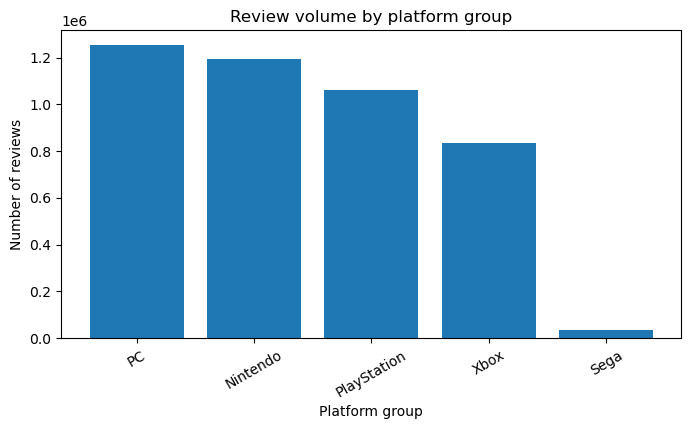

In [26]:
platform_pd = platform_summary_df.toPandas()

plt.figure(figsize=(8, 4))
plt.bar(platform_pd["platform_group"], platform_pd["review_count"])
plt.title("Review volume by platform group")
plt.xlabel("Platform group")
plt.ylabel("Number of reviews")
plt.xticks(rotation=30)
plt.show()


## 13. Time-based trends

For presentation purposes, this section focuses on the **mature part of the timeline** rather than ultra-sparse early months.
We keep the full monthly aggregation for reproducibility, then automatically choose the first month with at least
`MIN_MONTHLY_REVIEWS_FOR_TRENDS` reviews and plot trends from there onward.


In [27]:
MIN_MONTHLY_REVIEWS_FOR_TRENDS = 100

monthly_trend_df = (
    base_df
    .groupBy("review_year_month")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_vote")
    )
    .orderBy("review_year_month")
)

trend_start_month = (
    monthly_trend_df
    .filter(F.col("review_count") >= MIN_MONTHLY_REVIEWS_FOR_TRENDS)
    .agg(F.min("review_year_month").alias("trend_start_month"))
    .first()[0]
)

if trend_start_month is None:
    trend_start_month = monthly_trend_df.agg(F.min("review_year_month")).first()[0]

monthly_trend_focus_df = (
    monthly_trend_df
    .filter(F.col("review_year_month") >= F.lit(trend_start_month))
    .orderBy("review_year_month")
)

print(f"Trend plots start from: {trend_start_month} (minimum {MIN_MONTHLY_REVIEWS_FOR_TRENDS} reviews in a month)")
monthly_trend_focus_df.show(24, truncate=False)


Trend plots start from: 1999-11-01 02:00:00 (minimum 100 reviews in a month)
+-------------------+------------+------------------+------------------+
|review_year_month  |review_count|avg_rating        |avg_helpful_vote  |
+-------------------+------------+------------------+------------------+
|1999-11-01 00:00:00|163         |4.184049079754601 |19.14723926380368 |
|1999-12-01 00:00:00|279         |4.057347670250896 |11.89605734767025 |
|2000-01-01 00:00:00|246         |3.9186991869918697|8.84959349593496  |
|2000-02-01 00:00:00|175         |4.011428571428572 |11.525714285714285|
|2000-03-01 00:00:00|178         |4.129213483146067 |9.573033707865168 |
|2000-04-01 00:00:00|264         |4.268939393939394 |8.238636363636363 |
|2000-05-01 00:00:00|308         |4.10064935064935  |8.035714285714286 |
|2000-06-01 00:00:00|353         |4.181303116147308 |6.4390934844192635|
|2000-07-01 00:00:00|425         |4.051764705882353 |6.402352941176471 |
|2000-08-01 00:00:00|499         |4.21643286573

In [28]:
verified_monthly_sql = spark.sql(
    '''
    SELECT
        review_year_month,
        verified_purchase,
        COUNT(*) AS review_count,
        ROUND(AVG(rating), 4) AS avg_rating
    FROM video_game_reviews
    GROUP BY review_year_month, verified_purchase
    ORDER BY review_year_month, verified_purchase
    '''
)

verified_monthly_focus_sql = (
    verified_monthly_sql
    .filter(F.col("review_year_month") >= F.lit(trend_start_month))
    .orderBy("review_year_month", "verified_purchase")
)

verified_monthly_focus_sql.show(24, truncate=False)


+-------------------+-----------------+------------+----------+
|review_year_month  |verified_purchase|review_count|avg_rating|
+-------------------+-----------------+------------+----------+
|1999-11-01 00:00:00|false            |156         |4.1667    |
|1999-11-01 00:00:00|true             |7           |4.5714    |
|1999-12-01 00:00:00|false            |272         |4.0441    |
|1999-12-01 00:00:00|true             |7           |4.5714    |
|2000-01-01 00:00:00|false            |240         |3.9167    |
|2000-01-01 00:00:00|true             |6           |4.0       |
|2000-02-01 00:00:00|false            |170         |3.9882    |
|2000-02-01 00:00:00|true             |5           |4.8       |
|2000-03-01 00:00:00|false            |172         |4.1802    |
|2000-03-01 00:00:00|true             |6           |2.6667    |
|2000-04-01 00:00:00|false            |251         |4.2709    |
|2000-04-01 00:00:00|true             |13          |4.2308    |
|2000-05-01 00:00:00|false            |3

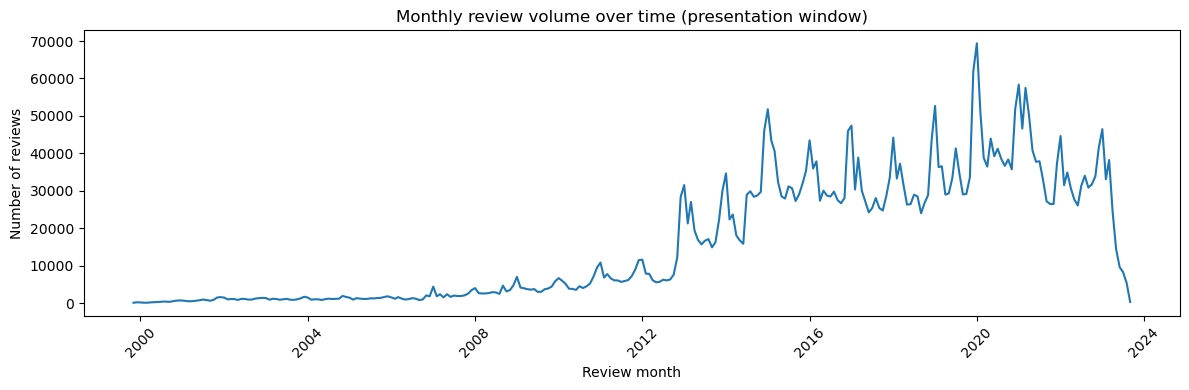

In [29]:
monthly_pd = monthly_trend_focus_df.toPandas().sort_values("review_year_month")

plt.figure(figsize=(12, 4))
plt.plot(monthly_pd["review_year_month"], monthly_pd["review_count"])
plt.title("Monthly review volume over time (presentation window)")
plt.xlabel("Review month")
plt.ylabel("Number of reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


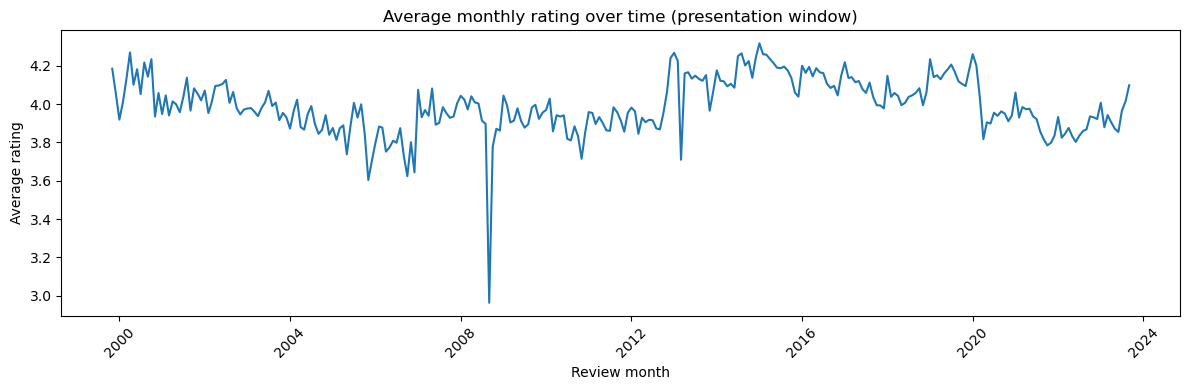

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_pd["review_year_month"], monthly_pd["avg_rating"])
plt.title("Average monthly rating over time (presentation window)")
plt.xlabel("Review month")
plt.ylabel("Average rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Optional focused business cuts

In [31]:
price_band_df = (
    base_df
    .withColumn(
        "price_band",
        F.when(F.col("price_value").isNull(), "Missing")
         .when(F.col("price_value") < 20, "<20")
         .when(F.col("price_value") < 40, "20-39.99")
         .when(F.col("price_value") < 60, "40-59.99")
         .otherwise("60+")
    )
    .groupBy("price_band")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_vote")
    )
    .orderBy("price_band")
)

price_band_df.show(truncate=False)


+----------+------------+------------------+------------------+
|price_band|review_count|avg_rating        |avg_helpful_vote  |
+----------+------------+------------------+------------------+
|20-39.99  |962670      |4.08359562466889  |1.1971911454600226|
|40-59.99  |443849      |4.097630049859299 |1.2348411284017762|
|60+       |771208      |4.069302963662203 |1.6555585522971754|
|<20       |1050064     |4.0797294260159385|1.0305219491383382|
|Missing   |1396824     |3.9702940384758567|1.1593966025784208|
+----------+------------+------------------+------------------+



## 15. Save selected aggregated outputs for reuse

In [32]:
(
    rating_summary_sql
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "notebook4_rating_distribution"))
)

(
    verified_behavior_df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "notebook4_verified_behavior"))
)

(
    top_categories_df
    .limit(50)
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "notebook4_top_categories"))
)

print("Selected outputs saved under results/")


Selected outputs saved under results/


## 16. Summary

In Notebook 4, we carried out the main Spark-based analytical stage of the project on top of the processed dataset created in Notebook 3. The notebook was built around a reusable analytical base table containing 4.62 million reviews, 137 thousand products, and 2.77 million users, with the key analytical columns already cleaned and normalized. From a technical perspective, this notebook demonstrates loading and validating a parquet-based analytical dataset, performing transformations with the PySpark DataFrame API, registering temporary views for Spark SQL, analyzing semi-structured fields through array explosion, applying joins and aggregations at scale, and using window functions to rank products within platform groups. It also includes practical optimization elements such as selective caching of reused DataFrames, inspection of execution plans with explain(True), and a broadcast-join strategy for the small platform-mapping table.

Analytically, the notebook shows that customer sentiment in the Amazon Video Games ecosystem is strongly positive overall: 61.15% of reviews are 5-star reviews, and roughly three quarters are rated 4 or 5 stars. Verified-purchase reviews dominate the dataset and have higher average ratings, while non-verified reviews are longer and receive substantially more helpful votes. Helpful-vote activity is highly skewed, with most reviews receiving no helpful votes at all and lower-rated reviews attracting the strongest engagement, especially among non-verified purchases. Category and platform analysis further show that the dataset covers not only game titles but also the wider gaming ecosystem, including accessories and platform-related products. Among the main platform groups, PC has the highest review volume, while Nintendo has the highest average rating. Time-based analysis shows strong growth in review activity in later years, while average monthly ratings remain relatively stable around 4.0. Overall, Notebook 4 demonstrates both meaningful business insight and technically sound use of Spark for large-scale analytical processing.

